### LA Lab1
Application of Eigenvectors
**Yelyzaveta Motorna**

**Task 1:** Computing Eigenvalues and Eigenvectors of a Matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [2]:
# set function
def eigenvectors_values(matx=np.ndarray):
    # check if matx is square
    if matx.shape[0] != matx.shape[1]:
        print('\033[91m', 'Not a square matrix', '\033[91m')
        return None, None

    # calc eigenvalues + eigenvectors
    eig_result = np.linalg.eig(matx)
    eigenvalues = np.real(eig_result[0])
    eigenvectors = np.real(eig_result[1])

    # check A⋅v=λ⋅v
    for i in range(matx.ndim):
        eigval =  eigenvalues[i]
        eigvec = eigenvectors[:,i]

        left = np.matmul(matx, eigvec)   # A⋅v
        right = eigval * eigvec          # λ⋅v

        if np.isclose(left, right).all():
            print('\033[92m' + 'Check passed' + '\033[0m')
            print(f"λ_{i+1} = {np.round(eigval, 2)} ; v_{i+1} = {np.round(eigvec,2)}")
        else:
            print('\033[91m', 'Check failed', '\033[91m')

    return eigenvalues, eigenvectors



In [3]:
# examples
print('Test 1 -----------------------')
test_matx = np.array([[1, 2],
                        [2, 1]])
print('Matrix:', test_matx)
test_eigval, test_eigvec = eigenvectors_values(test_matx)



print('Test 2 -----------------------')
nonsq_matx = np.array([[1,2],
                       [3, 2],
                       [5, 0]])
print('Matrix:', nonsq_matx)
nsq_eigval, nsq_eigvec = eigenvectors_values(nonsq_matx)



Test 1 -----------------------
Matrix: [[1 2]
 [2 1]]
Check passed
λ_1 = 3.0 ; v_1 = [0.71 0.71]
Check passed
λ_2 = -1.0 ; v_2 = [-0.71  0.71]
Test 2 -----------------------
Matrix: [[1 2]
 [3 2]
 [5 0]]
 Not a square matrix 


**Task 2:** Implementation of Image Dimensionality Reduction Using PCA

Image dimensions in pixels: (6120, 8160) ;  Main color channels: 3 (RGB)


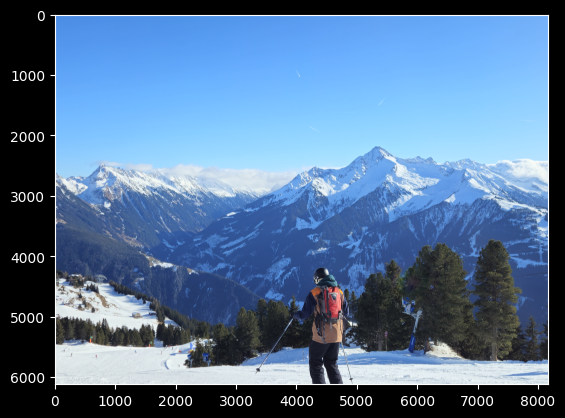

In [4]:
# vector of original color image
plt.style.use('dark_background')  # to prevent color distortion <= dark theme

image_raw = imread('LA_Lab1_photo.jpg')
im_shape = image_raw.shape
print(f'Image dimensions in pixels: {im_shape[:2]} ;  Main color channels: {im_shape[2]} (RGB)')

# original color image
plt.imshow(image_raw)
plt.show()



Black-white image size: (6120, 8160) ; Color channels: 1


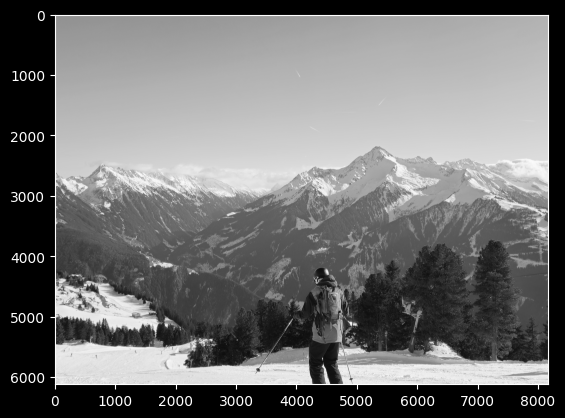

In [5]:
# convert to black/white
bw_image = image_raw.sum(axis=2)  # sum along 3rd RGB dimension => 2D-matrix
print('Black-white image size:', bw_image.shape, '; Color channels: 1')

# display image
plt.imshow(bw_image, cmap='gray')
plt.show()


Covariance matrix: (8160, 8160)
Check passed
λ_1 = 35517312.44 ; v_1 = [0.01 0.01 0.01 ... 0.01 0.01 0.01]
Check passed
λ_2 = 5151666.43 ; v_2 = [-0.02 -0.02 -0.02 ...  0.01  0.01  0.01]


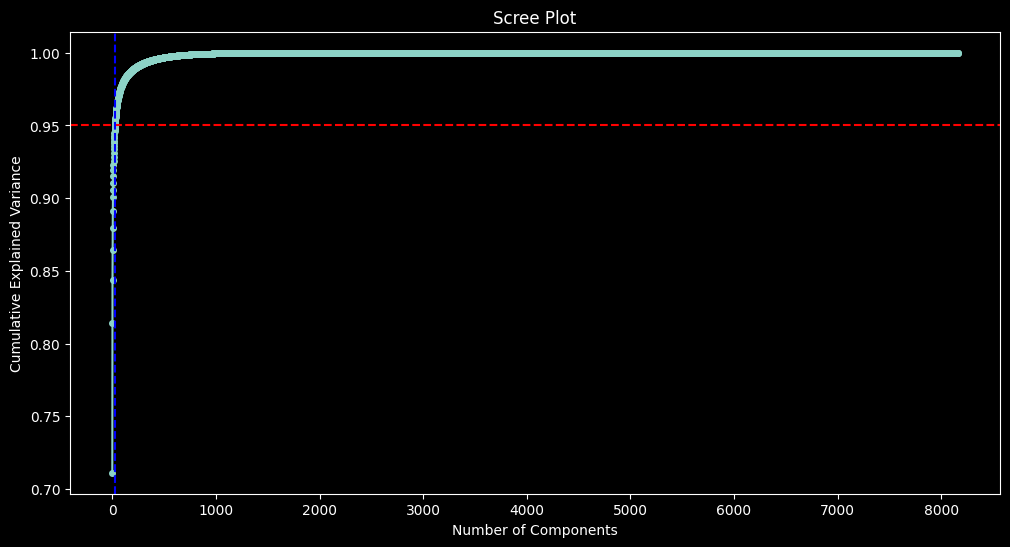

Number of components to retain for 95% variance: 27
Total number of components: 8160


In [6]:
# Apply PCA to the image_bw component matrix. Display cumulative variance and find the number of components needed to cover 95% of the variance

# normalize values
mean_values = np.mean(bw_image, axis=0)
std_values = np.std(bw_image, axis=0)
bw_img_norm = (bw_image - mean_values) / std_values

# covvar matx
cov_matx = np.matmul(bw_img_norm.T, bw_img_norm)
# check size
print('Covariance matrix:',cov_matx.shape)

# find eig val/vec
eigval_img, eigvec_img = eigenvectors_values(cov_matx)
# sort desc \\ max eigenvalue = PCA1
eigval_sorted = np.sort(eigval_img)[::-1]
# -> %
eigval_ratio = eigval_sorted / np.sum(eigval_sorted)
cum_varr = np.cumsum(eigval_ratio)

# scree plot
plt.figure(figsize=(12, 6))
plt.plot(cum_varr, 'o-', markersize=4)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')

plt.axhline(y=0.95, color='r', linestyle='--') # 95% variance threshold
plt.axvline(x=27, color='b', linestyle='--')   # x explain 95% 

plt.show()

#   #components explain 95% of varr
num_components = np.where(cum_varr >= 0.95)[0][0] + 1
print(f'Number of components to retain for 95% variance: {num_components}')
print('Total number of components:', len(eigval_ratio))




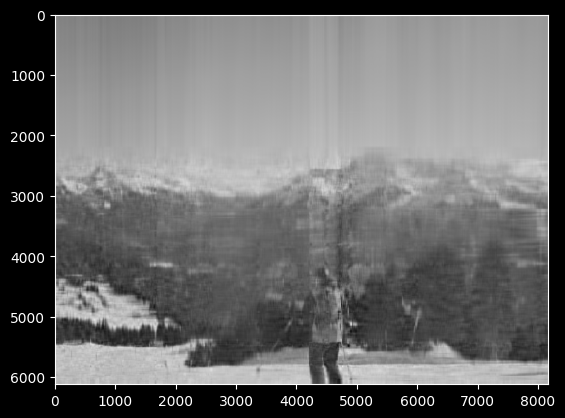

In [7]:
# Reconstruct the black and white image using the limited number of components found in the previous step. Display the resulting image

indices = np.argsort(eigval_img)[::-1][:num_components]
eigvec_components = eigvec_img[:,indices]

# project image onto eigenvectors
bw_img_reduced = np.matmul(bw_img_norm, eigvec_components) 
# reconstruct image => prev dim
bw_img_reconstructed = np.matmul(bw_img_reduced, eigvec_components.T)

plt.imshow(bw_img_reconstructed, cmap='gray')
plt.show()


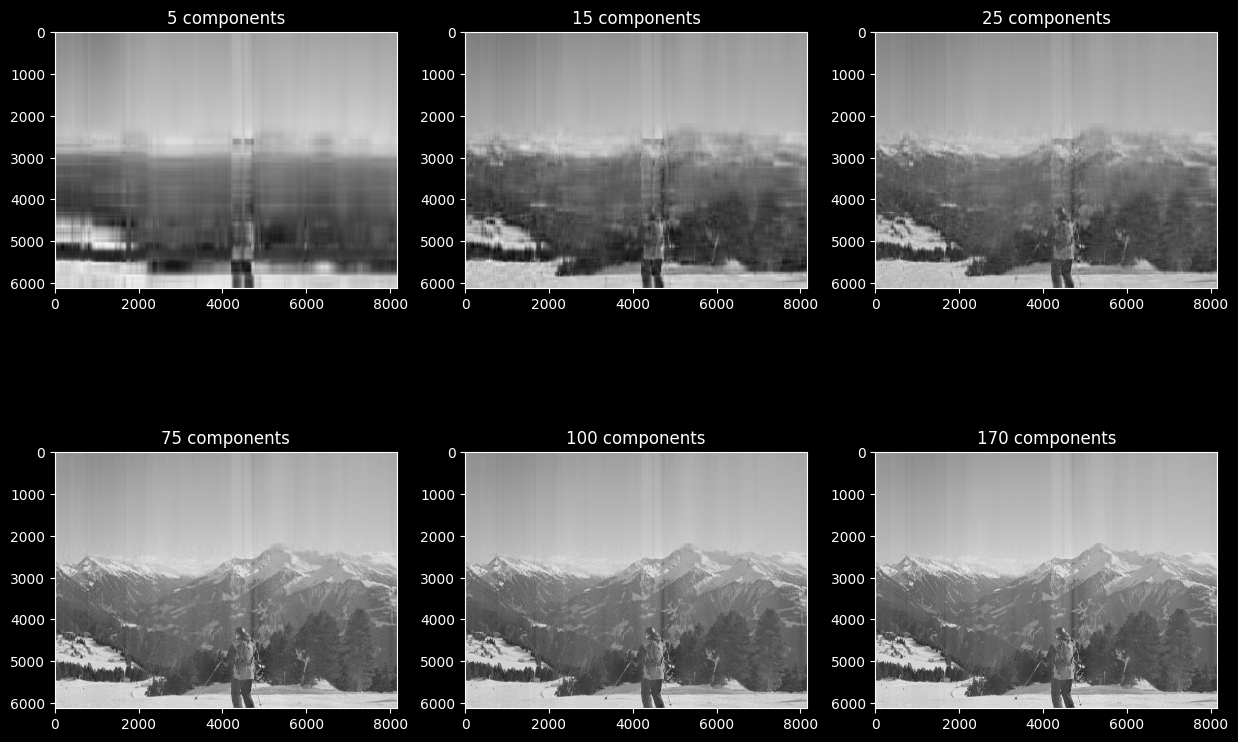

In [8]:
# Reconstruct the image for different numbers of components and display the corresponding results. Try taking a larger number of components and display the results

pc_to_check = [5, 15, 25, 75, 100, 170]

plt.figure(figsize=(15, 10))

for i, k in zip(pc_to_check, range(1, len(pc_to_check)+1)):
    inds = np.argsort(eigval_img)[::-1][:i]
    eigvecs = eigvec_img[:,inds]
    
    # project image onto eigenvectors
    img_reduced = np.matmul(bw_img_norm, eigvecs) 
    # reconstruct image => prev dim
    img_reconstructed = np.matmul(img_reduced, eigvecs.T)
    
    plt.subplot(2, 3, k)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'{i} components')
    
plt.show()





**Task 3:** Using Diagonalization, Eigenvalues and Eigenvectors in Cryptography

In [48]:
# encrypting func
def encrypt_message(message, key_matrix):
    
    message_vector = np.array([ord(char) for char in message])
    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)
    diagonalized_key_matrix = np.dot(np.dot(eigenvectors, np.diag(eigenvalues)), np.linalg.inv(eigenvectors))
    encrypted_vector = np.dot(diagonalized_key_matrix, message_vector)
    
    return encrypted_vector


# decrypting func
def decrypt_message(encrypted_vector, key_matrix):

    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)
    diagonalized_key_matrix = np.dot(np.dot(eigenvectors, np.diag(eigenvalues)), np.linalg.inv(eigenvectors))  # TDT_-1
    
    diag_inv = np.linalg.inv(diagonalized_key_matrix)
    
    decrypted_vector = np.dot(diag_inv, encrypted_vector)
    decrypted_vector = np.real(decrypted_vector)
    decrypt = [chr(int(i)) for i in decrypted_vector]
    
    message = ''.join(decrypt)
    
    return message


# check
message = 'Hello, World!'
matx = np.random.randint(0, 256, (len(message), len(message)))

encrypted = encrypt_message(message, matx)
decrypted = decrypt_message(encrypted, matx)

print(decrypted)

Heklo,Vorkc!
